# [실습 13-1] Gymnasium FrozenLake로 Q-러닝 구현

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 40~50분 (CPU 충분) |
| 본문 연계 | 13.3 Q-러닝 (그리드월드와 동일 구조) |
| 선수 실습 | 없음 (부록 B.3 권장) |
| 준비 | 부록 B.1·B.3 참고 |

본문 그리드월드와 같은 구조의 얼음 호수(4×4)에서 에이전트가
**시행착오만으로** 길을 배우는 것을 확인한다 — 갱신식 한 줄이
학습의 전부다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 세 줄의 주석을 해제하고 실행)
# !git clone https://github.com/tbgoodlife/ai-labs.git
# %cd ai-labs
# !pip -q install gymnasium
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch13/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from utils import plot_style, viz

plot_style.apply()              # 도해 스타일 킷 적용
print("Python", platform.python_version())
print("NumPy", np.__version__,
      "/ Gymnasium", gym.__version__)


def greedy_run(env, Q, max_steps=100):
    """학습된 Q로 탐욕 주행(탐험 없이) — 성공 시 걸음 수."""
    s, _ = env.reset(seed=0)
    for step in range(1, max_steps + 1):
        s, r, term, trunc, _ = env.step(int(Q[s].argmax()))
        if term or trunc:
            return step if r > 0 else None
    return None

Python 3.12.6
NumPy 2.4.6 / Gymnasium 1.3.0


### [셀 1] 무대 확인 — 본문 그리드월드와 1:1 📖

In [2]:
import gymnasium as gym
import numpy as np

env = gym.make("FrozenLake-v1",
               desc=["SFFF", "FHFF", "FFFH", "HFFG"],
               is_slippery=False)
print(env.unwrapped.desc.astype(str))
n_s = env.observation_space.n
n_a = env.action_space.n
print(f"상태 {n_s}개 x 행동 {n_a}개")

[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'F']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]
상태 16개 x 행동 4개


**핵심 포인트**
- S(출발)·F(길)·H(웅덩이)·G(목표)는 본문 〈에이전트와 환경〉의 무대 그대로다. 상태 번호는 왼쪽 위부터 0, 목표가 15다.
- `is_slippery=False`가 "행동한 대로 움직이는" 결정적 모드다. 미끄러지는 확률적 모드는 저장소 [심화 2]에서.

### [보조 1] 시드 고정 (저장소 전용)

지면 수치 재현을 위해 탐험 행동 샘플러의 시드를 고정한다 — **건너뛰지 말고 실행**한다.

In [3]:
env.action_space.seed(13)   # 탐험(sample)의 재현성 고정
print("행동 샘플러 시드 고정 완료 — 아래 셀들이 지면과 같은 수치를 재현한다")

행동 샘플러 시드 고정 완료 — 아래 셀들이 지면과 같은 수치를 재현한다


### [셀 2] 손계산 재현 — 수첩의 첫 기록 📖

In [4]:
Q = np.zeros((n_s, n_a))     # 백지 수첩(64칸)
alpha, gamma = 0.1, 0.9      # 안전한 시작값

s, a, r, s2 = 14, 2, 1.0, 15   # 14에서 ->로 목표 도착
target = r + gamma * Q[s2].max()
Q[s, a] += alpha * (target - Q[s, a])
print(f"Q(14, ->) = {Q[s, a]:.3f}")

Q(14, ->) = 0.100


**핵심 포인트**
- 본문 〈Q-러닝 갱신식〉 에피소드 1의 손계산 그대로다. 0 + 0.1 × (1 + 0.9×0 − 0) = 0.100. 손과 코드가 같은 숫자를 낸다.
- `target - Q[s, a]`가 갱신식 대괄호 안의 "오차"다.

### [셀 3] 학습 루프 — 2,000판의 배달 📖

In [5]:
def train(eps, episodes=2000, seed=104):
    rng = np.random.default_rng(seed)
    Q = np.zeros((n_s, n_a))
    wins = []
    for ep in range(episodes):
        s, _ = env.reset(seed=int(rng.integers(1e6)))
        done = False
        while not done:
            if rng.random() < eps:            # 탐험
                a = env.action_space.sample()
            else:                             # 활용(동률 무작위)
                best = np.flatnonzero(Q[s] == Q[s].max())
                a = int(rng.choice(best))
            s2, r, term, trunc, _ = env.step(a)
            Q[s, a] += alpha * (r + gamma * Q[s2].max()
                                - Q[s, a])
            s, done = s2, term or trunc
        wins.append(r > 0)
    return Q, wins

Q1, w1 = train(eps=0.1)
rate1 = np.mean(w1[-100:])
print(f"e=0.1 마지막 100판 성공률: {rate1:.0%}")

e=0.1 마지막 100판 성공률: 92%


**핵심 포인트**
- 학습의 심장은 갱신 한 줄이다. 본문 수식과 기호 순서까지 같게 썼다(`r + gamma * Q[s2].max() - Q[s, a]`).
- if/else가 ε-greedy의 전부다. 열 번에 한 번 안 가본 길로 향한다. 활용 쪽의 "동률 무작위"는 백지 수첩(전부 0점 동률)에서 한 방향만 고집하지 않기 위한 안전장치다.

### [셀 4] 수첩 들여다보기 — Before/After 히트맵 📖

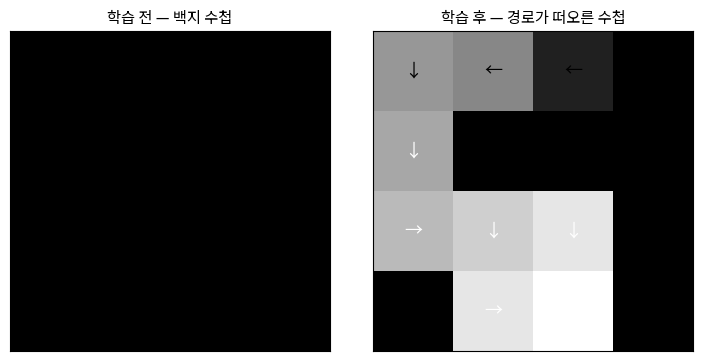

array([<Axes: title={'center': '학습 전 — 백지 수첩'}>,
       <Axes: title={'center': '학습 후 — 경로가 떠오른 수첩'}>], dtype=object)

In [6]:
viz.plot_qtable_heatmap(
    np.zeros((n_s, n_a)), Q1,
    titles=("학습 전 — 백지 수첩",
            "학습 후 — 경로가 떠오른 수첩"))

**핵심 포인트**
- 학습 후 히트맵에서 출발→목표 경로의 칸들이 밝게 떠오른다. [그림 13-2]의 실물이며, 값이 목표에 가까울수록 큰 것은 〈벨만 방정식〉의 γ 물결 그대로다.

### [셀 5] 탐험 과잉의 실측 — ε = 0.1 vs 0.9 📖

e=0.1 학습 후 탐욕 주행: 6걸음
e=0.9 학습 후 탐욕 주행: 6걸음


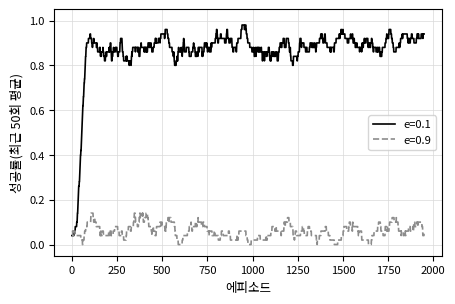

In [7]:
Q9, w9 = train(eps=0.9)
viz.plot_success_curves((w1, w9),
                        labels=("e=0.1", "e=0.9"))

for name, Q in (("e=0.1", Q1), ("e=0.9", Q9)):
    steps = greedy_run(env, Q)   # 탐험 끄고 주행
    print(f"{name} 학습 후 탐욕 주행: {steps}걸음")

**핵심 포인트**
- 학습 곡선을 보면 성공률이 ε=0.1은 92% 수준까지 오르지만 ε=0.9는 약 5%(학습곡선 기준)에 머문다. 학습 중 성적은 하늘과 땅인데, 학습 후 수첩대로 달리면 **둘 다 6걸음 최단 경로**다 — "탐험은 지식, 활용은 성과"의 실측 증거.
- ε 감소 스케줄로 두 장점을 잇는 실험은 저장소 [심화 2]에 뼈대가 있다(연습문제 구현 문항 직결).

### [보조 2] 학습된 정책의 에피소드 재생 (텍스트 렌더)

In [8]:
env_txt = gym.make("FrozenLake-v1",
                   desc=["SFFF", "FHFF", "FFFH", "HFFG"],
                   is_slippery=False,
                   render_mode="ansi")
s, _ = env_txt.reset(seed=0)
done, steps = False, 0
print(env_txt.render())
while not done and steps < 20:
    s, r, term, trunc, _ = env_txt.step(
        int(Q1[s].argmax()))
    done, steps = term or trunc, steps + 1
    print(env_txt.render())
print(f"{steps}걸음 만에 도착" if r else "실패")


SFFF
FHFF
FFFH
HFFG

  (Down)
SFFF
FHFF
FFFH
HFFG

  (Down)
SFFF
FHFF
FFFH
HFFG

  (Right)
SFFF
FHFF
FFFH
HFFG

  (Down)
SFFF
FHFF
FFFH
HFFG

  (Right)
SFFF
FHFF
FFFH
HFFG

  (Right)
SFFF
FHFF
FFFH
HFFG

6걸음 만에 도착


### [심화 1] α·γ·보상 변형 — 손계산 검산 슬롯 (연습문제 응용 직결)

In [9]:
# 연습문제 응용: "다른 조건으로 Q값 갱신 1~2스텝 계산"
# 문항을 손으로 푼 뒤, 아래에 같은 조건을 넣어 검산하자.
def one_update(Q_s_a, r, max_next, alpha, gamma):
    """갱신식 한 줄을 함수로 — 손계산 검산용."""
    return Q_s_a + alpha * (r + gamma * max_next - Q_s_a)

# 예: α=0.5, γ=0.8, 현재 Q=0.2, 보상 0, 다음 최댓값 0.5
print(f"{one_update(0.2, 0.0, 0.5, 0.5, 0.8):.3f}")
# TODO: 문제의 조건으로 바꿔 검산

0.300


### [심화 2] ε 감소 스케줄 + 미끄러운 호수 (연습문제 직결)

In [10]:
# TODO 1: 선형 감소 ε(1.0 → 0.05)로 train을 고쳐
#         [셀 5] 곡선에 세 번째 선을 추가하자 —
#         "처음엔 탐험, 갈수록 활용"의 효과 확인.
# TODO 2: is_slippery=True(확률적 환경)로 바꾸면
#         2,000판으로 충분한가? 에피소드 수·α를 조절하며
#         결정적 환경과의 차이를 해석하자.
def eps_linear(ep, episodes, hi=1.0, lo=0.05):
    return hi + (lo - hi) * ep / (episodes - 1)

print([round(eps_linear(e, 2000), 2)
       for e in (0, 500, 1000, 1500, 1999)])

[1.0, 0.76, 0.52, 0.29, 0.05]


---
## 마무리

- Q-러닝의 전부는 갱신식 한 줄이다 — 손계산([셀 2])과 600판 학습([셀 3])이 같은 줄을 쓴다.
- Q-테이블 히트맵에서 가치가 목표로부터 번져 나오는 것(γ 전파)과, 화살표가 곧 정책임을 봤다.
- 탐험(지식)과 활용(성과)은 별개의 화폐다 — ε=0.9도 결국 길은 배웠다([셀 5]). 실전형 절충이 ε 감소 스케줄이다.

**연습문제 연계**: [응용] Q값 갱신 계산은 [심화 1]로 검산, [응용] ε 스케줄 비교는 [심화 2]에서 수행한다.

**다음 장**: 14장 — [실습 14-1] 공정성 지표 계산 (`ch14/lab-14-01_fairness-metrics.ipynb`)